### Load relevant libraries

In [28]:
import os
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### Read in the data

In [29]:
# Set working directory (necessary until 2019 data comes out)
path = 'C:/Users/caanm/OneDrive/Documents/Project Portfolio/March Madness 2026/2026 Data'
os.chdir(path)

In [55]:
Pruned_Predictions = pd.read_csv('2026_full_prediction.csv', sep=',', index_col=None)
Pruned_Predictions.head()

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff,pred
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0,0.790232
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0,0.099033
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0,0.022631
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0,0.788535
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0,0.877881


In [31]:
Pruned_Predictions['win_pruned'] = Pruned_Predictions.apply(lambda Pruned_Predictions: ('Win' if Pruned_Predictions['pred'] > 0.5 else 'Loss'), axis=1)
Pruned_Predictions = Pruned_Predictions.rename(columns={'pred':'pred_pruned'})
display(Pruned_Predictions.head(), Pruned_Predictions.shape)

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff,pred_pruned,win_pruned
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0,0.790232,Win
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0,0.099033,Loss
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0,0.022631,Loss
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0,0.788535,Win
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0,0.877881,Win


(132133, 37)

In [32]:
XGBoost_Predictions = pd.read_csv('kaggle_submission_XGBoost.csv', sep=',', index_col=None)
XGBoost_Predictions.head()

,ID,pred
0,2026_1101_1102,0.794551
1,2026_1101_1103,0.437790
2,2026_1101_1104,0.007104
3,2026_1101_1105,0.715502
4,2026_1101_1106,0.882329


In [33]:
XGBoost_Predictions['win_XGBoost'] = XGBoost_Predictions.apply(lambda XGBoost_Predictions: ('Win' if XGBoost_Predictions['pred'] > 0.5 else 'Loss'), axis=1)
XGBoost_Predictions = XGBoost_Predictions.rename(columns={'pred':'pred_XGBoost'})
display(XGBoost_Predictions.head(), XGBoost_Predictions.shape)

,ID,pred_XGBoost,win_XGBoost
0,2026_1101_1102,0.794551,Win
1,2026_1101_1103,0.437790,Loss
2,2026_1101_1104,0.007104,Loss
3,2026_1101_1105,0.715502,Win
4,2026_1101_1106,0.882329,Win


(132133, 3)

### Merge the data

In [34]:
Ensemble_Predictions = Pruned_Predictions.merge(XGBoost_Predictions, how='inner', on='ID')

In [35]:
Ensemble_Predictions.head()

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff,pred_pruned,win_pruned,pred_XGBoost,win_XGBoost
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0,0.790232,Win,0.794551,Win
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0,0.099033,Loss,0.437790,Loss
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0,0.022631,Loss,0.007104,Loss
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0,0.788535,Win,0.715502,Win
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0,0.877881,Win,0.882329,Win


### Calculate Ensemble Predictions and Differences

In [36]:
Ensemble_Predictions['pred_ensemble'] = 0.5 * Ensemble_Predictions['pred_pruned'] + 0.5 * Ensemble_Predictions['pred_XGBoost']
Ensemble_Predictions['win_ensemble'] = Ensemble_Predictions.apply(lambda Ensemble_Predictions: ('Win' if Ensemble_Predictions['pred_ensemble'] > 0.5 else 'Loss'), axis=1)

Ensemble_Predictions.head()

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff,pred_pruned,win_pruned,pred_XGBoost,win_XGBoost,pred_ensemble,win_ensemble
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0,0.790232,Win,0.794551,Win,0.792391,Win
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0,0.099033,Loss,0.437790,Loss,0.268412,Loss
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0,0.022631,Loss,0.007104,Loss,0.014868,Loss
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0,0.788535,Win,0.715502,Win,0.752018,Win
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0,0.877881,Win,0.882329,Win,0.880105,Win


In [37]:
Ensemble_Predictions['flip_from_pruned'] = (Ensemble_Predictions['pred_ensemble'] > 0.5) != (Ensemble_Predictions['pred_pruned'] > 0.5)
display(Ensemble_Predictions.head(),Ensemble_Predictions.shape)

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff,pred_pruned,win_pruned,pred_XGBoost,win_XGBoost,pred_ensemble,win_ensemble,flip_from_pruned
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0,0.790232,Win,0.794551,Win,0.792391,Win,False
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0,0.099033,Loss,0.437790,Loss,0.268412,Loss,False
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0,0.022631,Loss,0.007104,Loss,0.014868,Loss,False
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0,0.788535,Win,0.715502,Win,0.752018,Win,False
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0,0.877881,Win,0.882329,Win,0.880105,Win,False


(132133, 42)

In [38]:
print('# of matchups with different predictions:', sum(Ensemble_Predictions['flip_from_pruned']))
print('% difference:', round(sum(Ensemble_Predictions['flip_from_pruned'])/len(Ensemble_Predictions)*100,0))

# of matchups with different predictions: 5464
% difference: 4.0


In [39]:
Ensemble_Predictions['flip_from_XGBoost'] = (Ensemble_Predictions['pred_ensemble'] > 0.5) != (Ensemble_Predictions['pred_XGBoost'] > 0.5)
display(Ensemble_Predictions.head(),Ensemble_Predictions.shape)

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff,pred_pruned,win_pruned,pred_XGBoost,win_XGBoost,pred_ensemble,win_ensemble,flip_from_pruned,flip_from_XGBoost
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0,0.790232,Win,0.794551,Win,0.792391,Win,False,False
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0,0.099033,Loss,0.437790,Loss,0.268412,Loss,False,False
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0,0.022631,Loss,0.007104,Loss,0.014868,Loss,False,False
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0,0.788535,Win,0.715502,Win,0.752018,Win,False,False
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0,0.877881,Win,0.882329,Win,0.880105,Win,False,False


(132133, 43)

In [40]:
print('# of matchups with different predictions:', sum(Ensemble_Predictions['flip_from_XGBoost']))
print('% difference:', round(sum(Ensemble_Predictions['flip_from_XGBoost'])/len(Ensemble_Predictions)*100,0))

# of matchups with different predictions: 5522
% difference: 4.0


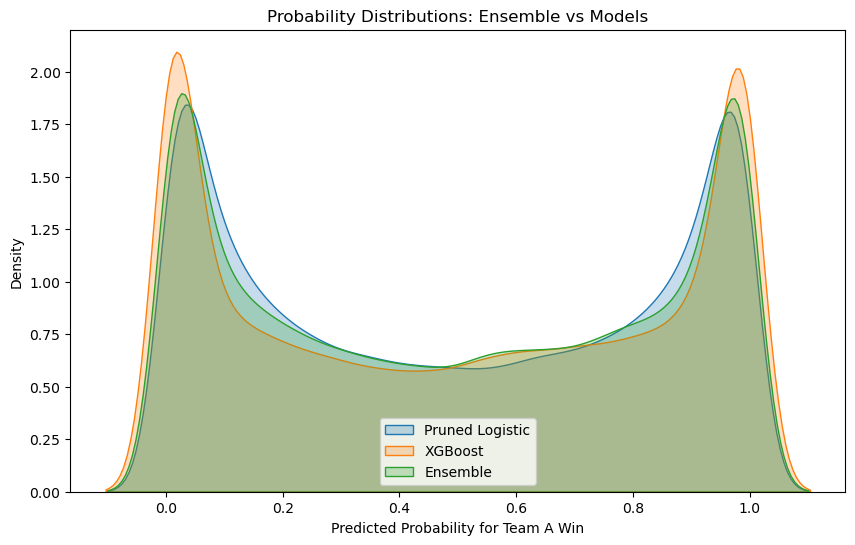

In [41]:
### Plot probability distributions among models
plt.figure(figsize=(10,6))
sns.kdeplot(Ensemble_Predictions['pred_pruned'], label='Pruned Logistic', fill=True)
sns.kdeplot(Ensemble_Predictions['pred_XGBoost'], label='XGBoost', fill=True)
sns.kdeplot(Ensemble_Predictions['pred_ensemble'], label='Ensemble', fill=True)
plt.xlabel('Predicted Probability for Team A Win')
plt.ylabel('Density')
plt.title('Probability Distributions: Ensemble vs Models')
plt.legend()
plt.show()

##### The Ensemble model predicts 4% of matchups differently from each of the XGBoost and Pruned Logistic models
##### Flipped matchups represent uncertain games, where the Logistic model's linear assumptions differ from XGBoost's nonlinear splits
##### Ensemble model adds value with these uncertainties: by averaging probabilities, the model reduces overconfidence from either model
##### This can be seen in the probability distribution chart
> ##### The Ensemble model brings down the number of matchups with prediction at the tails, compared to XGBoost
> ##### Similarly, it flattens the predictions around the mid-mark (0.1-0.3, 0.7-0.9), compared to Logistic

#### Ensemble Model Drivers

In [42]:
# Define selected variables from Pruned model
Pruned_selected_variables = (['top_a', 'mid_a', 'top_b', 'mid_b', 'efg_diff', 'pt_diff',
       'winsbefore_diff', 'winsafter_diff', 'clutch_diff', 'to_diff',
       'blk_diff', 'seed_diff', 'conf_diff', 'winpercintourney_diff'])

X_pruned = Ensemble_Predictions[Pruned_selected_variables]
X_pruned.head()

,top_a,mid_a,top_b,mid_b,efg_diff,pt_diff,winsbefore_diff,winsafter_diff,clutch_diff,to_diff,blk_diff,seed_diff,conf_diff,winpercintourney_diff
0,0,0,0,0,0.012355,1.423609,1.069862,1.638688,1.225215,0.033051,0.199582,0.0,-5.0,0.000000
1,0,0,0,1,-2.251365,-2.100164,-2.010044,-2.458032,-0.490086,1.035358,-0.321067,12.0,5.0,0.000000
2,0,0,0,0,-1.295543,-1.626981,-1.703855,-1.433852,-1.225215,1.412570,-2.598910,4.0,-10.0,-0.554167
3,0,0,1,0,-0.567607,-0.393840,-0.600029,-0.637268,0.000000,1.023143,-0.173550,0.0,17.0,0.000000
4,0,0,0,0,0.113182,0.015048,0.423810,0.102418,0.816810,0.328563,-1.257397,0.0,17.0,-0.125000


In [43]:
# Drop any variables without any variation
# These are from missing data and should be empty once the full 2026 data is released (games after day 90, tournament seeds)
constant_cols = X_pruned.columns[X_pruned.nunique() <= 1]
print("Constant columns:", constant_cols)

Constant columns: Index([], dtype='object')


In [44]:
X_corr = X_pruned.drop(columns=constant_cols)

In [45]:
# Correlation 
ensemble_corr = X_corr.corrwith(pd.Series(Ensemble_Predictions['pred_ensemble']))
ensemble_corr_sorted = ensemble_corr.sort_values(ascending=False)
display(ensemble_corr_sorted)

winsbefore_diff          0.805788
pt_diff                  0.804534
conf_diff                0.764230
efg_diff                 0.667949
winpercintourney_diff    0.527503
winsafter_diff           0.419618
blk_diff                 0.344544
clutch_diff              0.289795
top_a                    0.183108
mid_a                    0.124313
mid_b                   -0.118335
top_b                   -0.224666
seed_diff               -0.329179
to_diff                 -0.460412
dtype: float64

##### Interpreting correlation results
> ##### Each value is a Pearson correlation between a feature and ensemble model's predicted probability
> ##### Positive correlations tend to increase pred
> ##### Negative correlations tend to decrease pred
> ##### Closer to 1 means a stronger linear relationship

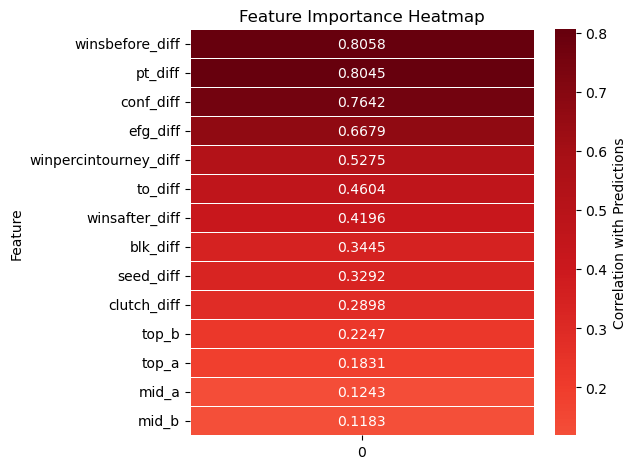

In [46]:
ensemble_corr_sorted = ensemble_corr.abs().sort_values(ascending=False)

sns.heatmap(
    ensemble_corr_sorted.to_frame(),
    annot=True,
    cmap='Reds',
    center=0,
    cbar_kws={'label': 'Correlation with Predictions'},
    fmt='.4f',
    linewidths=0.5
)
plt.title('Feature Importance Heatmap')
plt.xlabel('')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### Takeaways
##### Largest drivers are regular season success, point differential, conference strength (>0.75 correlation)
##### efg% and historical success in the postseason are secondary drivers (>0.5) - important, but not as decisive
##### Several minor contributors provide smaller signals, but may refine predictions in closer matchups
> ##### Some of their effects may already be captured by other variables
##### blk_diff has a negligible effect in ensemble predictions (<0.02)

#### Comparing against individual models
##### pt_diff, winpercintourney_diff, and winsbefore_diff were mainly the strongest drivers in both Logistic and XGBoost models
##### conf_diff was the second strongest in the XGBoost model
##### It's interesting to see features like efg_diff and to_diff see increased importance in the ensemble model
> ##### Neither had much importance in the Logistic model 
> ##### Both were dropped from the XGBoost model
##### Ensemble models can amplify secondary signals that singular models may have downweighted

### Print results for submission

In [47]:
pred = Ensemble_Predictions.copy()
pred.head()

,ID,season,team_a,team_b,top_a,mid_a,bot_a,winpercintourney_a,top_b,mid_b,bot_b,winpercintourney_b,efg_diff,sa_diff,pt_diff,rank_diff,winsbefore_diff,winsafter_diff,clutch_diff,close_diff,grit_diff,has_ot_diff,off_diff,def_diff,ast_diff,to_diff,stl_diff,blk_diff,or_diff,dr_diff,3m_diff,3a_diff,winpercintourney_diff,seed_diff,conf_diff,pred_pruned,win_pruned,pred_XGBoost,win_XGBoost,pred_ensemble,win_ensemble,flip_from_pruned,flip_from_XGBoost
0,2026_1101_1102,2026,1101,1102,0,0,1,0.0,0,0,1,0.000000,0.012355,0.005922,1.423609,-10,1.069862,1.638688,1.225215,1.530036,-1.275128,0.776104,0.777178,-0.852825,0.166156,0.033051,2.270736,0.199582,1.472500,-1.102741,-0.562947,-0.851300,0.000000,0.0,-5.0,0.790232,Win,0.794551,Win,0.792391,Win,False,False
1,2026_1101_1103,2026,1101,1103,0,0,1,0.0,0,1,0,0.000000,-2.251365,-3.056251,-2.100164,6,-2.010044,-2.458032,-0.490086,1.192528,-1.275128,0.776104,-2.299416,-0.089896,-2.353718,1.035358,1.342448,-0.321067,-0.689408,-3.141422,-3.098032,-2.551838,0.000000,12.0,5.0,0.099033,Loss,0.437790,Loss,0.268412,Loss,False,False
2,2026_1101_1104,2026,1101,1104,0,0,1,0.0,0,0,1,0.554167,-1.295543,-4.791134,-1.626981,-1,-1.703855,-1.433852,-1.225215,0.180004,-2.527158,0.048507,-2.887421,-1.362923,-1.582609,1.412570,1.806592,-2.598910,-1.049727,-4.145318,-4.137600,-4.306484,-0.554167,4.0,-10.0,0.022631,Loss,0.007104,Loss,0.014868,Loss,False,False
3,2026_1101_1105,2026,1101,1105,0,0,1,0.0,1,0,0,0.000000,-0.567607,0.022296,-0.393840,7,-0.600029,-0.637268,0.000000,0.720017,-2.527158,0.000000,-0.416788,0.000000,0.572824,1.023143,1.942265,-0.173550,0.384339,-1.960429,-0.505801,-0.107185,0.000000,0.0,17.0,0.788535,Win,0.715502,Win,0.752018,Win,False,False
4,2026_1101_1106,2026,1101,1106,0,0,1,0.0,0,0,1,0.125000,0.113182,-1.803973,0.015048,-6,0.423810,0.102418,0.816810,0.789696,-1.275128,0.776104,-0.434932,-0.527163,0.348717,0.328563,0.987717,-1.257397,-1.183393,-1.764864,-1.043607,-1.293140,-0.125000,0.0,17.0,0.877881,Win,0.882329,Win,0.880105,Win,False,False


In [48]:
pred = pred[['ID','pred_ensemble']].rename(columns={'pred_ensemble':'pred'})
pred.head()

,ID,pred
0,2026_1101_1102,0.792391
1,2026_1101_1103,0.268412
2,2026_1101_1104,0.014868
3,2026_1101_1105,0.752018
4,2026_1101_1106,0.880105


In [49]:
pred.to_csv('kaggle_submission_ensemble.csv', index=False)

##### Merge with Team Name data frame to more easily fill out brackets

In [50]:
submission = pd.concat([pred, pred['ID'].str.split('_', expand=True).rename(
    columns={0:'season', 1:'team_a', 2:'team_b'})], axis=1)

submission[['team_a','team_b']] = submission[['team_a','team_b']].astype(int)

submission.head()

,ID,pred,season,team_a,team_b
0,2026_1101_1102,0.792391,2026,1101,1102
1,2026_1101_1103,0.268412,2026,1101,1103
2,2026_1101_1104,0.014868,2026,1101,1104
3,2026_1101_1105,0.752018,2026,1101,1105
4,2026_1101_1106,0.880105,2026,1101,1106


In [51]:
M_Teams = pd.read_csv("MTeams.csv", sep=',', index_col=None)
W_Teams = pd.read_csv("WTeams.csv", sep=',', index_col=None)
Teams = pd.concat([M_Teams,W_Teams])
#Teams['TeamID'] = Teams['TeamID'].astype(object)

Teams.head()

,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014.0,2026.0
1,1102,Air Force,1985.0,2026.0
2,1103,Akron,1985.0,2026.0
3,1104,Alabama,1985.0,2026.0
4,1105,Alabama A&M,2000.0,2026.0


In [52]:
result1 = submission.merge(Teams, how='left', left_on='team_a', right_on='TeamID').rename(
    columns={'TeamName':'team_a_name'}).drop(['TeamID','FirstD1Season','LastD1Season'], axis=1)
result2 = result1.merge(Teams, how='left', left_on='team_b', right_on='TeamID').rename(
    columns={'TeamName':'team_b_name'}).drop(['TeamID','FirstD1Season','LastD1Season'], axis=1)
display(result2.head(), result2.shape)

,ID,pred,season,team_a,team_b,team_a_name,team_b_name
0,2026_1101_1102,0.792391,2026,1101,1102,Abilene Chr,Air Force
1,2026_1101_1103,0.268412,2026,1101,1103,Abilene Chr,Akron
2,2026_1101_1104,0.014868,2026,1101,1104,Abilene Chr,Alabama
3,2026_1101_1105,0.752018,2026,1101,1105,Abilene Chr,Alabama A&M
4,2026_1101_1106,0.880105,2026,1101,1106,Abilene Chr,Alabama St


(132133, 7)

### Bracket Predictions

In [53]:
results_for_bracket = result2[['team_a','team_a_name','team_b','team_b_name','pred']]
results_for_bracket.to_csv('bracket_submission_ensemble.csv', index=False)